# Solar PV prediction — clean data, evaluation harness, and reference baselines

## tl;dr

This notebook completes Phases 1–3: it writes `dataset/solaredge_clean.parquet`,
provides a leakage-safe leave-systems-out evaluation harness, and evaluates
training-mean and calibrated GHI reference baselines.
The verified run contains **1,387,682 daylight rows across 37 systems**;
**1,370,191 rows are modeling-ready** and 17,491 remain available with QC
flags for audit. The roadmap currently says 36 systems, but the supplied
input contains 37. Every system is held out exactly once with training-only
preprocessing. The calibrated GHI baseline reaches **0.1237 macro nRMSE**, a
**42.7% reduction** from the training-mean baseline, and has lower nRMSE on
all 37 held-out systems.

## Context & Methods

The combined CSV is the output of the already-completed load/weather-join
step. Its clock times are Hong Kong local time and are localized—not
converted—to `Asia/Hong_Kong`.

### Key Assumptions

- All systems in the combined table share one campus weather source.
- `cell_temp_ghi` intentionally uses GHI instead of POA because several systems
  combine arrays with mixed or multiple orientations.
- A likely daytime fault zero is zero power while GHI is at least 200 W/m².
- A stuck sensor is an unchanged value for at least four consecutive hours.
- A data gap is a raw-series interval longer than the expected 15 minutes.

QC is non-destructive: flagged daylight rows remain in the Parquet file.
Downstream modeling should filter to `modeling_ready == True`.

In [18]:
import importlib.util
import subprocess
import sys

# Install into the active notebook kernel, not a different system Python.
if importlib.util.find_spec("pvlib") is None:
    print(f"Installing pvlib into {sys.executable} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pvlib"])

from pathlib import Path

import numpy as np
import pandas as pd
import pvlib

SITE = dict(latitude=22.3364, longitude=114.2654, altitude=60)
TIMEZONE = "Asia/Hong_Kong"

INPUT_PATH = Path("dataset/site_level_dataset_modified_combined.csv")
OUTPUT_PATH = Path("dataset/solaredge_clean.parquet")

GHI_COL = "Irradiance (W/m2)"
TEMP_COL = "Temp (Degree Celsius)"
WIND_COL = "Wind Speed (m/s)"
RH_COL = "RH (%)"
POWER_COL = "power(W)"
GROUP_COL = "station"
TARGET_COL = "y_norm"

WEATHER_FEATURES = [GHI_COL, TEMP_COL, WIND_COL, RH_COL]
PHYSICS_FEATURES = [
    "zenith", "azimuth", "clearsky_ghi",
    "clearsky_index", "cell_temp_ghi",
]
MODEL_COLUMNS = WEATHER_FEATURES + PHYSICS_FEATURES + [TARGET_COL]

EXPECTED_INTERVAL = pd.Timedelta(minutes=15)
STUCK_MIN_SAMPLES = 16  # 4 hours at 15-minute resolution
FAULT_ZERO_GHI = 200.0

## Data

### 1. Load and validate the combined site-level table

In [19]:
df = pd.read_csv(INPUT_PATH, parse_dates=["Time"]).rename(
    columns={"Time": "timestamp"}
)
if df["timestamp"].dt.tz is None:
    df["timestamp"] = df["timestamp"].dt.tz_localize(TIMEZONE)

df = df.sort_values([GROUP_COL, "timestamp"]).reset_index(drop=True)
assert not df.duplicated([GROUP_COL, "timestamp"]).any(),             "Duplicate (station, timestamp) rows found"

# Detect raw-series gaps before daylight filtering, so nights are not
# mistaken for missing data.
df["gap_from_previous_min"] = (
    df.groupby(GROUP_COL, sort=False)["timestamp"]
      .diff().dt.total_seconds().div(60)
)
df["flag_after_gap"] = df["gap_from_previous_min"].gt(
    EXPECTED_INTERVAL.total_seconds() / 60
)

n_systems = df[GROUP_COL].nunique()
assert n_systems == 37, f"Expected 37 systems in the combined table, found {n_systems}"
assert df["total_capacity_W"].notna().all(), "Missing system capacity in combined table"
assert df["total_capacity_W"].gt(0).all(), "System capacity must be positive"
assert df.groupby(GROUP_COL)["total_capacity_W"].nunique().eq(1).all(),             "A station has inconsistent capacity values in the combined table"

print(f"Loaded {len(df):,} rows from {n_systems} systems.")
print(f"Time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Raw data-gap events: {df['flag_after_gap'].sum():,}")

Loaded 2,756,516 rows from 37 systems.
Time range: 2021-06-01 00:00:00+08:00 to 2023-12-31 23:45:00+08:00
Raw data-gap events: 956


## Feature Engineering

### 2. Add solar position and keep daylight rows

In [20]:
location = pvlib.location.Location(tz=TIMEZONE, **SITE)
unique_times = pd.DatetimeIndex(df["timestamp"].unique()).sort_values()
solar_position = location.get_solarposition(unique_times)

solar_features = pd.DataFrame({
    "timestamp": unique_times,
    "zenith": solar_position["apparent_zenith"].to_numpy(),
    "azimuth": solar_position["azimuth"].to_numpy(),
})
df = df.merge(solar_features, on="timestamp", how="left", validate="many_to_one")

rows_before_daylight = len(df)
df = df.loc[df["zenith"].lt(90)].copy()
df = df.sort_values([GROUP_COL, "timestamp"]).reset_index(drop=True)

print(f"Daylight rows: {len(df):,} / {rows_before_daylight:,}")
print(f"Maximum retained zenith: {df['zenith'].max():.4f}°")

Daylight rows: 1,387,682 / 2,756,516
Maximum retained zenith: 89.9997°


### 3. Add clear-sky, temperature, and normalized-power features

In [21]:
weather_variation = df.groupby("timestamp")[WEATHER_FEATURES].nunique(dropna=False)
assert not weather_variation.gt(1).any().any(),             "Weather columns vary by station at the same timestamp"

daylight_times = pd.DatetimeIndex(df["timestamp"].unique()).sort_values()
clearsky = location.get_clearsky(daylight_times, model="ineichen")
clearsky_by_time = pd.DataFrame({
    "timestamp": daylight_times,
    "clearsky_ghi": clearsky["ghi"].to_numpy(),
})
df = df.merge(clearsky_by_time, on="timestamp", how="left", validate="many_to_one")

df["clearsky_index"] = pvlib.irradiance.clearsky_index(
    df[GHI_COL], df["clearsky_ghi"], max_clearsky_index=2.0
)
df["cell_temp_ghi"] = pvlib.temperature.faiman(
    poa_global=df[GHI_COL],
    temp_air=df[TEMP_COL],
    wind_speed=df[WIND_COL],
    u0=25.0,
    u1=6.84,
)
df[TARGET_COL] = df[POWER_COL] / df["total_capacity_W"]

feature_ranges = df[
    ["clearsky_ghi", "clearsky_index", "cell_temp_ghi", TARGET_COL]
].agg(["min", "median", "max"]).T
feature_ranges

,min,median,max
clearsky_ghi,0.000010,562.962563,969.946851
clearsky_index,0.005821,0.627822,2.000000
cell_temp_ghi,6.027646,30.485748,89.249385
y_norm,0.000000,0.146361,0.993482


## Quality Control

### 4. Flag fault zeros, stuck sensors, missing/impossible values, and gaps

The flags preserve an audit trail. `flag_after_gap` is informational for
this tabular model because no lagged features are used; all other QC flags
determine `modeling_ready`.

In [22]:
def repeated_run_flag(frame, value_col, group_col=None):
    # Flag exact-value runs lasting at least STUCK_MIN_SAMPLES.
    same_value = frame[value_col].eq(frame[value_col].shift())
    same_interval = frame["timestamp"].diff().eq(EXPECTED_INTERVAL)
    same_group = (
        frame[group_col].eq(frame[group_col].shift())
        if group_col else pd.Series(True, index=frame.index)
    )
    run_id = (~(same_value & same_interval & same_group)).cumsum()
    run_length = frame.groupby(run_id, sort=False)[value_col].transform("size")
    return run_length.ge(STUCK_MIN_SAMPLES)


df = df.sort_values([GROUP_COL, "timestamp"]).reset_index(drop=True)
df["flag_power_stuck"] = (
    repeated_run_flag(df, POWER_COL, GROUP_COL) & df[POWER_COL].gt(0)
)

weather = (
    df.drop_duplicates("timestamp")[["timestamp"] + WEATHER_FEATURES]
      .sort_values("timestamp").reset_index(drop=True)
)
weather["flag_weather_stuck"] = False
for column in WEATHER_FEATURES:
    weather["flag_weather_stuck"] |= repeated_run_flag(weather, column)

df = df.merge(
    weather[["timestamp", "flag_weather_stuck"]],
    on="timestamp", how="left", validate="many_to_one",
)
df["flag_fault_zero"] = df[POWER_COL].eq(0) & df[GHI_COL].ge(FAULT_ZERO_GHI)
df["flag_missing"] = df[MODEL_COLUMNS].isna().any(axis=1)
df["flag_impossible"] = (
    df["total_capacity_W"].le(0)
    | df[GHI_COL].lt(0)
    | df[WIND_COL].lt(0)
    | (df[RH_COL].notna() & ~df[RH_COL].between(0, 100))
    | (df[TARGET_COL].notna() & ~df[TARGET_COL].between(-0.001, 1.2))
)

MODEL_EXCLUSION_FLAGS = [
    "flag_missing", "flag_impossible", "flag_fault_zero",
    "flag_power_stuck", "flag_weather_stuck",
]
df["modeling_ready"] = ~df[MODEL_EXCLUSION_FLAGS].any(axis=1)

qc_flags = ["flag_after_gap"] + MODEL_EXCLUSION_FLAGS
qc_summary = pd.DataFrame({
    "rows": df[qc_flags].sum().astype("int64"),
    "percent": df[qc_flags].mean().mul(100).round(3),
})
qc_summary

,rows,percent
flag_after_gap,731,0.053
flag_missing,16991,1.224
flag_impossible,0,0.000
flag_fault_zero,500,0.036
flag_power_stuck,0,0.000
flag_weather_stuck,0,0.000


## Results

### 5. Validate and save the Phase 1 table

In [23]:
ready = df["modeling_ready"]

assert df[GROUP_COL].nunique() == 37, "System count changed"
assert df["timestamp"].dt.tz is not None, "Timestamp lost its timezone"
assert df["zenith"].lt(90).all(), "Nighttime row survived"
assert df["clearsky_ghi"].gt(0).all(), "Non-positive clear-sky GHI found"
assert not df.duplicated([GROUP_COL, "timestamp"]).any(),             "Duplicate (station, timestamp) rows found"
assert df.loc[ready, MODEL_COLUMNS].notna().all().all(),             "Model-ready rows contain missing values"
assert not df.loc[ready, MODEL_EXCLUSION_FLAGS].any().any(),             "Model-ready rows contain an exclusion flag"

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df.to_parquet(OUTPUT_PATH, index=False, compression="zstd")

saved = pd.read_parquet(
    OUTPUT_PATH, columns=[GROUP_COL, "timestamp", "modeling_ready"]
)
assert len(saved) == len(df), "Saved Parquet row count changed"
assert saved[GROUP_COL].nunique() == 37, "Saved Parquet system count changed"
assert saved["timestamp"].dt.tz is not None, "Saved timestamp lost timezone"

phase1_summary = pd.Series({
    "systems": df[GROUP_COL].nunique(),
    "daylight_rows": len(df),
    "modeling_ready_rows": int(ready.sum()),
    "flagged_rows": int((~ready).sum()),
    "output_size_MB": round(OUTPUT_PATH.stat().st_size / 1_000_000, 1),
}, name="Phase 1 complete")
phase1_summary

systems                     37.0
daylight_rows          1387682.0
modeling_ready_rows    1370191.0
flagged_rows             17491.0
output_size_MB              56.3
Name: Phase 1 complete, dtype: float64

## Takeaways

- The final checks passed for 1,387,682 daylight rows across all 37 systems.
  Of these, 1,370,191 rows are marked modeling-ready.
- The export is intentionally non-destructive: use `modeling_ready` for the
  training subset while retaining flagged records for audit and threshold review.
- The roadmap's “36 systems” should be corrected to 37 unless one of the
  present site-level files is intentionally out of scope.
- The GHI-based features intentionally omit POA because several systems combine
  arrays with mixed or multiple orientations.

# Phase 2 — Build the evaluation harness

## Goal and evaluation contract

The harness below measures cold-start generalization to completely unseen PV
systems. Five-fold `GroupKFold` keeps every row from a station in the same fold.
Metrics are reported for each held-out system, rather than only pooling systems
with very different row counts.

### Key assumptions

- Evaluation uses only rows where `modeling_ready == True`.
- `y_norm` is power divided by installed capacity. Therefore RMSE on `y_norm` is
  capacity-normalized RMSE (nRMSE); 0.10 means 10% of capacity.
- MBE is defined as `prediction - observation`; positive MBE is overprediction.
- This is a system-generalization split, not a future-time forecasting split.
- Scaling is optional, but when enabled it is fitted independently inside each
  fold using training rows only.

In [24]:
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def normalized_regression_metrics(y_true, y_pred):
    """Return metrics in fractions of installed capacity for y_norm.

    MBE uses prediction minus observation, so positive values indicate
    systematic overprediction.
    """
    observed = np.asarray(y_true, dtype=float).reshape(-1)
    predicted = np.asarray(y_pred, dtype=float).reshape(-1)
    if observed.shape != predicted.shape or observed.size == 0:
        raise ValueError("Observed and predicted values must be non-empty and aligned")
    if not (np.isfinite(observed).all() and np.isfinite(predicted).all()):
        raise ValueError("Metrics require finite observed and predicted values")

    error = predicted - observed
    return {
        "nRMSE": float(np.sqrt(np.mean(np.square(error)))),
        "MAE": float(np.mean(np.abs(error))),
        "MBE": float(np.mean(error)),
    }

## Leave-systems-out loop

The function accepts any scikit-learn-compatible regressor. It clones a fresh
model for every fold, asserts train/test station disjointness, checks that the
scaler learned the training-fold mean and row count, and returns both fold-level
and per-system results.

In [25]:
def evaluate_leave_systems_out(
    data,
    estimator,
    feature_columns,
    *,
    target_column=TARGET_COL,
    group_column=GROUP_COL,
    n_splits=5,
    scale_features=True,
    random_state=42,
):
    """Evaluate a regressor on unseen systems with leakage guards."""
    required = list(feature_columns) + [target_column, group_column, "modeling_ready"]
    missing = sorted(set(required) - set(data.columns))
    if missing:
        raise KeyError(f"Missing evaluation columns: {missing}")
    if target_column != TARGET_COL:
        raise ValueError(f"nRMSE is defined here for the capacity-normalized target {TARGET_COL!r}")

    evaluation = data.loc[data["modeling_ready"], required].copy()
    if evaluation[required].isna().any().any():
        raise ValueError("Model-ready evaluation data contains missing values")
    n_systems = evaluation[group_column].nunique()
    if not 2 <= n_splits <= n_systems:
        raise ValueError(f"n_splits must be between 2 and {n_systems}")

    X = evaluation.loc[:, feature_columns]
    y = evaluation[target_column]
    groups = evaluation[group_column]
    splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_rows = []
    system_rows = []
    fitted_models = []
    tested_systems = []

    for fold, (train_index, test_index) in enumerate(
        splitter.split(X, y, groups=groups), start=1
    ):
        train_systems = set(groups.iloc[train_index])
        test_systems = set(groups.iloc[test_index])
        assert train_systems.isdisjoint(test_systems), (
            f"Fold {fold}: a test system leaked into training"
        )

        steps = []
        if scale_features:
            steps.append(("scaler", StandardScaler()))
        steps.append(("regressor", clone(estimator)))
        fitted = Pipeline(steps).fit(X.iloc[train_index], y.iloc[train_index])

        if scale_features:
            scaler = fitted.named_steps["scaler"]
            np.testing.assert_allclose(
                scaler.mean_,
                X.iloc[train_index].mean().to_numpy(),
                rtol=1e-10,
                atol=1e-12,
                err_msg=f"Fold {fold}: scaler was not fitted on training data only",
            )
            scaler_counts = np.asarray(scaler.n_samples_seen_)
            assert np.all(scaler_counts == len(train_index)), (
                f"Fold {fold}: scaler row count differs from training fold"
            )

        predictions = fitted.predict(X.iloc[test_index])
        fold_metrics = normalized_regression_metrics(y.iloc[test_index], predictions)
        fold_rows.append({
            "fold": fold,
            "n_train_rows": len(train_index),
            "n_test_rows": len(test_index),
            "n_train_systems": len(train_systems),
            "n_test_systems": len(test_systems),
            "observation_mean": float(y.iloc[test_index].mean()),
            "prediction_mean": float(np.mean(predictions)),
            "prediction_min": float(np.min(predictions)),
            "prediction_max": float(np.max(predictions)),
            **fold_metrics,
        })

        test_groups = groups.iloc[test_index].reset_index(drop=True)
        test_observed = y.iloc[test_index].reset_index(drop=True)
        predictions = np.asarray(predictions)
        for system in sorted(test_systems):
            system_mask = test_groups.eq(system).to_numpy()
            system_rows.append({
                "fold": fold,
                group_column: system,
                "n_test_rows": int(system_mask.sum()),
                **normalized_regression_metrics(
                    test_observed.to_numpy()[system_mask], predictions[system_mask]
                ),
            })
            tested_systems.append(system)
        fitted_models.append(fitted)

    expected_systems = set(evaluation[group_column].unique())
    assert set(tested_systems) == expected_systems, "Not every system was evaluated"
    assert len(tested_systems) == len(expected_systems), (
        "A system appeared in more than one test fold"
    )

    return {
        "fold_results": pd.DataFrame(fold_rows),
        "system_results": pd.DataFrame(system_rows).sort_values(group_column).reset_index(drop=True),
        "models": fitted_models,
    }

## Checks — execute the full harness

A training-mean regressor is used only as a fast end-to-end smoke test. Phase 3
can reuse the same function for formal baselines, and Phase 4 can pass Models A
and B with their respective feature lists. The system-level macro average below
weights each PV system equally.

In [26]:
phase2_smoke_test = evaluate_leave_systems_out(
    df,
    DummyRegressor(strategy="mean"),
    WEATHER_FEATURES,
    n_splits=5,
    scale_features=True,
    random_state=42,
)

fold_results = phase2_smoke_test["fold_results"]
system_results = phase2_smoke_test["system_results"]
assert len(fold_results) == 5
assert len(system_results) == df.loc[df["modeling_ready"], GROUP_COL].nunique() == 37
assert system_results[GROUP_COL].is_unique
assert system_results[["nRMSE", "MAE", "MBE"]].notna().all().all()

system_metric_summary = (
    system_results[["nRMSE", "MAE", "MBE"]]
    .agg(["mean", "std", "min", "max"])
    .T
    .rename_axis("metric")
)
print("Leakage guards passed: 37 systems were each held out exactly once.")
display(fold_results.round(4))
display(system_metric_summary.round(4))
display(system_results.head(10).round(4))

Leakage guards passed: 37 systems were each held out exactly once.


,fold,n_train_rows,n_test_rows,n_train_systems,n_test_systems,observation_mean,prediction_mean,prediction_min,prediction_max,nRMSE,MAE,MBE
0,1,1134334,235857,29,8,0.2219,0.2226,0.2226,0.2226,0.2123,0.1777,0.0007
1,2,1074653,295538,29,8,0.2250,0.2218,0.2218,0.2218,0.2192,0.1826,-0.0032
2,3,1075610,294581,30,7,0.2320,0.2199,0.2199,0.2199,0.2203,0.1834,-0.0121
3,4,1126795,243396,30,7,0.2225,0.2225,0.2225,0.2225,0.2119,0.1775,-0.0000
4,5,1069372,300819,30,7,0.2112,0.2257,0.2257,0.2257,0.2164,0.1813,0.0145


,mean,std,min,max
metric,,,,
nRMSE,0.2160,0.0185,0.1711,0.2424
MAE,0.1811,0.0130,0.1507,0.2006
MBE,-0.0013,0.0329,-0.0399,0.1059


,fold,station,n_test_rows,nRMSE,MAE,MBE
0,3,Indoor_Sport_Center,36201,0.2211,0.1877,0.0144
1,3,LSK_North,45453,0.2266,0.1877,-0.0287
2,4,LSK_South,43093,0.2397,0.1969,-0.0399
3,4,Library,26626,0.2007,0.1690,0.0068
4,1,SQ1,45224,0.2158,0.1806,-0.0124
5,3,SQ2,45455,0.2207,0.1815,-0.0139
6,1,SQ3,45458,0.2177,0.1806,-0.0070
7,5,SQ4,45460,0.2349,0.1937,-0.0281
8,2,SQ567,43841,0.2326,0.1932,-0.0290
9,2,SQ_Apartment13_24,42174,0.2295,0.1913,-0.0210


## Phase 2 takeaways

- The reusable evaluator isolates entire systems with `GroupKFold`.
- Metrics are available at both fold and held-out-system levels.
- Explicit assertions prevent group overlap, missing model inputs, repeated test
  systems, and preprocessing fitted on anything other than training rows.
- Later phases can compare models fairly by calling the same function with the
  same folds, random seed, target, and metric definitions.

# Phase 3 — Build reference baselines

## Goal and baseline definitions

Phase 3 establishes two reference points for the later ML models. The trivial
baseline predicts the training-fold mean of capacity-normalized power. The GHI
baseline uses a one-parameter physical signal:

`solar_signal = (clearsky_ghi / 1000) * clearsky_index`

A nonnegative scale is fitted through the origin using training rows only, and
predictions are clipped to the accepted `y_norm` range `[0, 1.2]`. This is a
calibrated GHI reference, not full PVWatts: system-level tilt and azimuth are
not reliable for rooftops that aggregate arrays with multiple orientations.

### Key assumptions

- Both baselines use the same five shuffled `GroupKFold` splits as Phase 2.
- The GHI scale is shared across training systems and cannot adapt to a held-out system.
- Scaling is disabled because the GHI estimator depends on physical input units.
- System-level macro averages weight each of the 37 PV systems equally.

In [27]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_is_fitted


class GHIPhysicsRegressor(BaseEstimator, RegressorMixin):
    """Capacity-normalized GHI baseline with one training-only scale."""

    required_features = ("clearsky_ghi", "clearsky_index")

    def __init__(self, prediction_ceiling=1.2):
        self.prediction_ceiling = prediction_ceiling

    def _solar_signal(self, X):
        if not isinstance(X, pd.DataFrame):
            raise TypeError("GHIPhysicsRegressor requires a pandas DataFrame")
        missing = sorted(set(self.required_features) - set(X.columns))
        if missing:
            raise KeyError(f"Missing GHI physics features: {missing}")

        feature_values = X.loc[:, self.required_features].to_numpy(dtype=float)
        if not np.isfinite(feature_values).all():
            raise ValueError("GHI physics features must be finite")
        if (feature_values < 0).any():
            raise ValueError("GHI physics features must be nonnegative")

        return (feature_values[:, 0] / 1000.0) * feature_values[:, 1]

    def fit(self, X, y):
        if not np.isfinite(self.prediction_ceiling) or self.prediction_ceiling <= 0:
            raise ValueError("prediction_ceiling must be finite and positive")

        signal = self._solar_signal(X)
        target = np.asarray(y, dtype=float).reshape(-1)
        if signal.shape != target.shape or target.size == 0:
            raise ValueError("Training features and target must be non-empty and aligned")
        if not np.isfinite(target).all():
            raise ValueError("Training target must be finite")

        signal_energy = float(np.dot(signal, signal))
        if signal_energy <= 0:
            raise ValueError("Training fold has no positive GHI physics signal")

        self.scale_ = max(0.0, float(np.dot(signal, target) / signal_energy))
        self.n_features_in_ = X.shape[1]
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        return self

    def predict(self, X):
        check_is_fitted(self, attributes=["scale_"])
        prediction = self.scale_ * self._solar_signal(X)
        return np.clip(prediction, 0.0, self.prediction_ceiling)

## Run both baselines

The formal mean baseline is rerun without unnecessary feature scaling. Both
models use identical split parameters so station-level results can be paired.

In [28]:
PHASE3_N_SPLITS = 5
PHASE3_RANDOM_STATE = 42
PHASE3_METRICS = ["nRMSE", "MAE", "MBE"]
GHI_BASELINE_FEATURES = ["clearsky_ghi", "clearsky_index"]

training_mean_baseline = evaluate_leave_systems_out(
    df,
    DummyRegressor(strategy="mean"),
    [GHI_COL],  # Required by the estimator API but ignored by DummyRegressor.
    n_splits=PHASE3_N_SPLITS,
    scale_features=False,
    random_state=PHASE3_RANDOM_STATE,
)

ghi_physics_baseline = evaluate_leave_systems_out(
    df,
    GHIPhysicsRegressor(prediction_ceiling=1.2),
    GHI_BASELINE_FEATURES,
    n_splits=PHASE3_N_SPLITS,
    scale_features=False,
    random_state=PHASE3_RANDOM_STATE,
)

phase3_runs = {
    "training_mean": training_mean_baseline,
    "ghi_physics": ghi_physics_baseline,
}
phase3_system_results = pd.concat(
    [result["system_results"].assign(model=name) for name, result in phase3_runs.items()],
    ignore_index=True,
).loc[:, ["model", "fold", GROUP_COL, "n_test_rows", *PHASE3_METRICS]]

phase3_fold_results = pd.concat(
    [result["fold_results"].assign(model=name) for name, result in phase3_runs.items()],
    ignore_index=True,
)
phase3_fold_results = phase3_fold_results.loc[
    :, ["model", *[column for column in phase3_fold_results.columns if column != "model"]]
]

phase3_physics_parameters = pd.DataFrame([
    {
        "model": "ghi_physics",
        "fold": fold,
        "scale": fitted.named_steps["regressor"].scale_,
        "prediction_ceiling": fitted.named_steps["regressor"].prediction_ceiling,
    }
    for fold, fitted in enumerate(ghi_physics_baseline["models"], start=1)
])

## Checks — folds, bounds, and determinism

These assertions extend the Phase 2 leakage checks by confirming paired folds,
finite physical parameters, bounded predictions, and deterministic reruns.

In [29]:
expected_systems = set(df.loc[df["modeling_ready"], GROUP_COL].unique())
assert len(expected_systems) == 37
assert len(phase3_system_results) == 2 * len(expected_systems)
assert phase3_system_results.groupby("model")[GROUP_COL].nunique().eq(37).all()
assert phase3_system_results.groupby(["model", GROUP_COL]).size().eq(1).all()
assert np.isfinite(phase3_system_results[PHASE3_METRICS].to_numpy()).all()

fold_assignment = phase3_system_results.pivot(
    index=GROUP_COL, columns="model", values="fold"
)
assert set(fold_assignment.index) == expected_systems
assert fold_assignment["training_mean"].eq(fold_assignment["ghi_physics"]).all(), (
    "Baselines did not use identical held-out-system folds"
)

assert np.isfinite(phase3_physics_parameters["scale"]).all()
assert phase3_physics_parameters["scale"].ge(0).all()
assert phase3_fold_results["prediction_min"].ge(-1e-12).all()
assert phase3_fold_results["prediction_max"].le(1.2 + 1e-12).all()

ghi_physics_repeat = evaluate_leave_systems_out(
    df,
    GHIPhysicsRegressor(prediction_ceiling=1.2),
    GHI_BASELINE_FEATURES,
    n_splits=PHASE3_N_SPLITS,
    scale_features=False,
    random_state=PHASE3_RANDOM_STATE,
)
pd.testing.assert_frame_equal(
    ghi_physics_baseline["fold_results"],
    ghi_physics_repeat["fold_results"],
)
pd.testing.assert_frame_equal(
    ghi_physics_baseline["system_results"],
    ghi_physics_repeat["system_results"],
)
print("Phase 3 checks passed: both baselines evaluated the same 37 systems deterministically.")

Phase 3 checks passed: both baselines evaluated the same 37 systems deterministically.


## Results — compare the reference baselines

The summary uses system-level macro averages. Relative reduction is reported
for nRMSE and MAE; MBE remains signed because zero, rather than a large positive
or negative percentage change, represents low bias.

In [30]:
phase3_summary = (
    phase3_system_results.groupby("model")[PHASE3_METRICS]
    .agg(["mean", "std", "median", "min", "max"])
)
phase3_summary.columns = ["_".join(column) for column in phase3_summary.columns]
phase3_summary = phase3_summary.reset_index()
system_counts = phase3_system_results.groupby("model")[GROUP_COL].nunique()
phase3_summary.insert(1, "n_systems", phase3_summary["model"].map(system_counts))

comparison_rows = []
for metric in PHASE3_METRICS:
    paired_metric = phase3_system_results.pivot(
        index=GROUP_COL, columns="model", values=metric
    )
    mean_reference = float(paired_metric["training_mean"].mean())
    mean_physics = float(paired_metric["ghi_physics"].mean())
    comparison_rows.append({
        "metric": metric,
        "training_mean": mean_reference,
        "ghi_physics": mean_physics,
        "physics_minus_mean": mean_physics - mean_reference,
        "relative_reduction_pct": (
            100.0 * (mean_reference - mean_physics) / mean_reference
            if metric in {"nRMSE", "MAE"} else np.nan
        ),
    })
phase3_comparison = pd.DataFrame(comparison_rows)

nrmse_pairs = phase3_system_results.pivot(
    index=GROUP_COL, columns="model", values="nRMSE"
)
physics_wins = int(nrmse_pairs["ghi_physics"].lt(nrmse_pairs["training_mean"]).sum())

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
phase3_system_results.to_csv(RESULTS_DIR / "phase3_system_results.csv", index=False)
phase3_fold_results.to_csv(RESULTS_DIR / "phase3_fold_results.csv", index=False)
phase3_summary.to_csv(RESULTS_DIR / "phase3_summary.csv", index=False)
phase3_physics_parameters.to_csv(
    RESULTS_DIR / "phase3_physics_parameters.csv", index=False
)

print(f"GHI physics has lower nRMSE on {physics_wins} of {len(nrmse_pairs)} systems.")
display(phase3_summary.round(4))
display(phase3_comparison.round(4))
display(phase3_physics_parameters.round(4))

GHI physics has lower nRMSE on 37 of 37 systems.


,model,n_systems,nRMSE_mean,nRMSE_std,nRMSE_median,nRMSE_min,nRMSE_max,MAE_mean,MAE_std,MAE_median,MAE_min,MAE_max,MBE_mean,MBE_std,MBE_median,MBE_min,MBE_max
0,ghi_physics,37,0.1237,0.0146,0.1294,0.0859,0.1447,0.0776,0.0111,0.0817,0.0474,0.0950,-0.0170,0.0345,-0.0313,-0.0708,0.0795
1,training_mean,37,0.2160,0.0185,0.2207,0.1711,0.2424,0.1811,0.0130,0.1833,0.1507,0.2006,-0.0013,0.0329,-0.0139,-0.0399,0.1059


,metric,training_mean,ghi_physics,physics_minus_mean,relative_reduction_pct
0,nRMSE,0.2160,0.1237,-0.0923,42.7422
1,MAE,0.1811,0.0776,-0.1035,57.1638
2,MBE,-0.0013,-0.0170,-0.0157,NaN


,model,fold,scale,prediction_ceiling
0,ghi_physics,1,0.6382,1.2
1,ghi_physics,2,0.6331,1.2
2,ghi_physics,3,0.6254,1.2
3,ghi_physics,4,0.6366,1.2
4,ghi_physics,5,0.6382,1.2


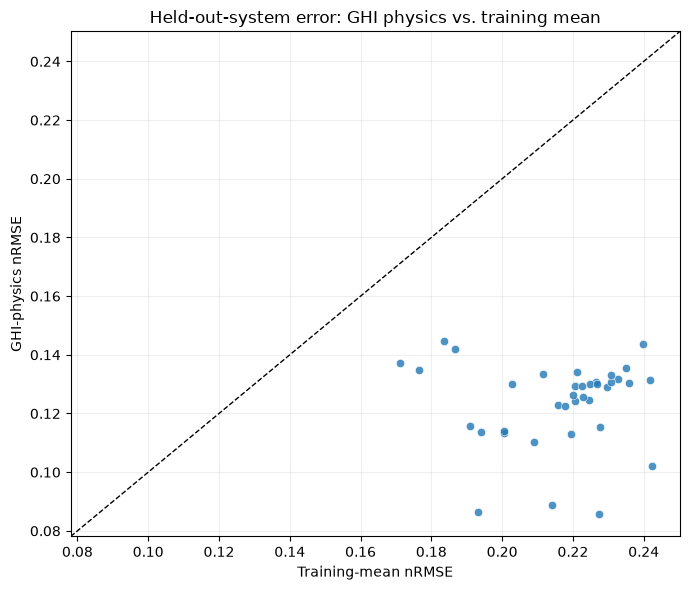

In [31]:
import matplotlib.pyplot as plt

plot_min = float(nrmse_pairs.min().min())
plot_max = float(nrmse_pairs.max().max())
plot_padding = 0.05 * (plot_max - plot_min)
plot_limits = (plot_min - plot_padding, plot_max + plot_padding)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    nrmse_pairs["training_mean"],
    nrmse_pairs["ghi_physics"],
    alpha=0.8,
    edgecolor="white",
    linewidth=0.5,
)
ax.plot(plot_limits, plot_limits, linestyle="--", color="black", linewidth=1)
ax.set(
    xlim=plot_limits,
    ylim=plot_limits,
    xlabel="Training-mean nRMSE",
    ylabel="GHI-physics nRMSE",
    title="Held-out-system error: GHI physics vs. training mean",
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Phase 3 takeaways

- Both baselines use identical held-out-system folds and training-only fitting; all checks pass.
- The calibrated GHI baseline reduces macro nRMSE from 0.2160 to 0.1237 (42.7%)
  and macro MAE from 0.1811 to 0.0776 (57.2%).
- GHI physics has lower nRMSE on all 37 systems, but its macro MBE is -0.0170,
  indicating a small average underprediction that later models should improve.
- The GHI model is a capacity-normalized reference, not full PVWatts; its five
  training-fold scales range from 0.6254 to 0.6382.
- Models A and B should beat 0.1237 macro nRMSE under the same folds. Reusable
  fold, system, summary, and fitted-parameter tables are saved under `results/`.

# Phase 4 — Train ML Models A and B

## Goal and experimental contract

Phase 4 is the controlled machine-learning comparison. Model A receives only
weather measurements; Model B receives the same weather measurements plus the
five GHI-based physics features created in Phase 1. Everything else—the XGBoost
estimator, hyperparameters, random seed, target, folds, and preprocessing—is held
constant so the paired difference isolates the value of the physics features.

The existing leave-systems-out harness fits five fresh copies of each estimator.
Each copy is trained only on its training systems and evaluated on systems it has
never seen. Tree models do not require feature scaling, so it is disabled here.

### Run instructions

1. Run the shared configuration cell; it installs XGBoost into the active
   notebook kernel automatically when the package is missing.
2. Review the shared configuration below. Do not tune Models A and B separately.
3. Set `RUN_PHASE4 = True` in the training cell and execute Phase 4 from top to bottom.

> **Safety:** `RUN_PHASE4` defaults to `False`, so an accidental **Run All** will
> configure the experiment without starting the ten cross-validation fits.


In [ ]:
import importlib
import subprocess
import sys

try:
    from xgboost import XGBRegressor
except ModuleNotFoundError as error:
    if error.name != "xgboost":
        raise
    print(f"Installing XGBoost into {sys.executable} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    importlib.invalidate_caches()
    from xgboost import XGBRegressor

MODEL_A_FEATURES = list(WEATHER_FEATURES)
MODEL_B_FEATURES = list(WEATHER_FEATURES) + list(PHYSICS_FEATURES)

PHASE4_N_SPLITS = 5
PHASE4_RANDOM_STATE = 42
PHASE4_METRICS = ["nRMSE", "MAE", "MBE"]
PHASE4_MODEL_CONFIG = {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 10,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "tree_method": "hist",
    "random_state": PHASE4_RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": 1,
}


def make_phase4_estimator():
    """Return a fresh XGBoost regressor with the shared Phase 4 settings."""
    return XGBRegressor(**PHASE4_MODEL_CONFIG)


# Validate the feature-only treatment difference before any expensive fitting.
assert MODEL_A_FEATURES == WEATHER_FEATURES
assert MODEL_B_FEATURES[:len(MODEL_A_FEATURES)] == MODEL_A_FEATURES
assert MODEL_B_FEATURES[len(MODEL_A_FEATURES):] == PHYSICS_FEATURES
assert len(MODEL_B_FEATURES) == len(set(MODEL_B_FEATURES))
assert set(MODEL_B_FEATURES).issubset(df.columns)
assert "poa_global" not in MODEL_B_FEATURES

phase4_design = pd.DataFrame({
    "model": ["model_a_weather", "model_b_hybrid"],
    "n_features": [len(MODEL_A_FEATURES), len(MODEL_B_FEATURES)],
    "features": [MODEL_A_FEATURES, MODEL_B_FEATURES],
})
print("XGBoost available in this kernel: True")
display(phase4_design)

,model,n_features,features
0,model_a_weather,4,"[Irradiance (W/m2), Temp (Degree Celsius), Win..."
1,model_b_hybrid,9,"[Irradiance (W/m2), Temp (Degree Celsius), Win..."


## Train both models on identical held-out-system folds

Change only the safety switch when ready. The two evaluator calls use identical
split settings and fresh estimators built from the same configuration. Training
can take substantial time because this performs ten fits over roughly 1.37 million
model-ready observations.


In [ ]:
RUN_PHASE4 = True

phase4_runs = None
if not RUN_PHASE4:
    print("Phase 4 training skipped. Set RUN_PHASE4 = True when ready.")
else:
    model_a_weather = evaluate_leave_systems_out(
        df,
        make_phase4_estimator(),
        MODEL_A_FEATURES,
        n_splits=PHASE4_N_SPLITS,
        scale_features=False,
        random_state=PHASE4_RANDOM_STATE,
    )
    model_b_hybrid = evaluate_leave_systems_out(
        df,
        make_phase4_estimator(),
        MODEL_B_FEATURES,
        n_splits=PHASE4_N_SPLITS,
        scale_features=False,
        random_state=PHASE4_RANDOM_STATE,
    )
    phase4_runs = {
        "model_a_weather": model_a_weather,
        "model_b_hybrid": model_b_hybrid,
    }
    print("Phase 4 training complete. Run the checks and summary cell next.")

## Checks and result tables

After training, this cell confirms that both models used the same held-out systems
in every fold, creates system-level macro summaries, computes paired B-minus-A
differences, and saves the Phase 4 tables under `results/`. Negative differences
for nRMSE or MAE mean that the hybrid model performed better.


In [ ]:
if phase4_runs is None:
    print("No Phase 4 results yet; training is intentionally disabled above.")
else:
    phase4_system_results = pd.concat(
        [
            run["system_results"].assign(model=model_name)
            for model_name, run in phase4_runs.items()
        ],
        ignore_index=True,
    ).loc[:, ["model", "fold", GROUP_COL, "n_test_rows", *PHASE4_METRICS]]

    phase4_fold_results = pd.concat(
        [
            run["fold_results"].assign(model=model_name)
            for model_name, run in phase4_runs.items()
        ],
        ignore_index=True,
    )
    phase4_fold_results = phase4_fold_results.loc[
        :, ["model", *[c for c in phase4_fold_results.columns if c != "model"]]
    ]

    fold_assignments = phase4_system_results.pivot(
        index=GROUP_COL, columns="model", values="fold"
    )
    assert fold_assignments.notna().all().all()
    assert fold_assignments["model_a_weather"].equals(
        fold_assignments["model_b_hybrid"]
    ), "Models A and B did not use identical held-out-system folds"
    assert phase4_system_results.groupby("model")[GROUP_COL].nunique().eq(37).all()
    assert np.isfinite(phase4_system_results[PHASE4_METRICS]).all().all()

    phase4_summary = (
        phase4_system_results.groupby("model")[PHASE4_METRICS]
        .agg(["mean", "std", "median", "min", "max"])
    )
    phase4_summary.columns = ["_".join(column) for column in phase4_summary.columns]
    phase4_summary = phase4_summary.reset_index()

    paired_metrics = phase4_system_results.pivot(
        index=GROUP_COL, columns="model", values=PHASE4_METRICS
    )
    phase4_paired_comparison = pd.DataFrame([
        {
            "metric": metric,
            "model_a_weather": paired_metrics[(metric, "model_a_weather")].mean(),
            "model_b_hybrid": paired_metrics[(metric, "model_b_hybrid")].mean(),
            "hybrid_minus_weather": (
                paired_metrics[(metric, "model_b_hybrid")].mean()
                - paired_metrics[(metric, "model_a_weather")].mean()
            ),
            "relative_error_reduction_pct": (
                100.0
                * (
                    paired_metrics[(metric, "model_a_weather")].mean()
                    - paired_metrics[(metric, "model_b_hybrid")].mean()
                )
                / paired_metrics[(metric, "model_a_weather")].mean()
                if metric in {"nRMSE", "MAE"}
                else np.nan
            ),
        }
        for metric in PHASE4_METRICS
    ])

    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    phase4_system_results.to_csv(
        RESULTS_DIR / "phase4_system_results.csv", index=False
    )
    phase4_fold_results.to_csv(
        RESULTS_DIR / "phase4_fold_results.csv", index=False
    )
    phase4_summary.to_csv(RESULTS_DIR / "phase4_summary.csv", index=False)
    phase4_paired_comparison.to_csv(
        RESULTS_DIR / "phase4_paired_comparison.csv", index=False
    )

    print("Phase 4 checks passed: Models A and B used identical held-out-system folds.")
    display(phase4_summary.round(4))
    display(phase4_paired_comparison.round(4))

No Phase 4 results yet; training is intentionally disabled above.


## Phase 4 handoff

- Model A uses the four weather measurements; Model B adds exactly five physics features.
- Both models share one XGBoost configuration and the Phase 2 leakage-safe evaluator.
- POA is intentionally excluded because system-level orientation is ambiguous for mixed arrays.
- Training and result generation remain disabled until `RUN_PHASE4` is explicitly set to `True`.
- Once executed, Phase 5 can combine the saved Phase 4 tables with the two Phase 3 baselines.
